 Dag 1 02/09 

Starting tasks:
* Verkrijgen van een functie voor de frequentie
* Verkrijgen van een FFT spectrum
* Een grafiek van de frequentie als gevolg van de lengte van de draad of de tijd

De functiegenerator stond origineel aangesloten op een osciloscoop, waarvan de instellingen orgineel verkeerd stonden. Na inschakelen van de TA's hebben ze 

Na een eerste poging om een mooi signiaal te krijgen kwamen we uiteindelijk tot de conclusie dat de magneten niet sterk genoeg waren om met een redelijke Vpp een sterk genoeg signiaal te krijgen om een goede meting te krijgen.
Als we zelf fysiek de draad lieten trillen dan kregen we een best goed signiaal voor een tijdje totdat die uitdempte.
Daarmee hebben we met behulp van een FFT(Fast Fouier Transform) een eerste boventoon kunnen vinden van 288.8 Hz


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### Python code voor laten zien FFT die we hebben gedownload

![Oepsie](FFT_228.png)

Na het uitleggen aan de TA's van wat we dachten dat aan de hand was is er gekeken naar of de magneet werkte en daaruit kwam de conclusie dat de magneet het inderdaad niet goed deed, en hebben we elke keer zelf de snaar doen trillen.

Nadat we een manier hadden gevonden om de data te verkrijgen hebben we een start meting gedaan en die gecurvefit voor de frequentie. Dit hebben we gedaan door de snaar te laten trillen en met een FFT met timebase van 2ms en een auto trigger.

234.17001068200443


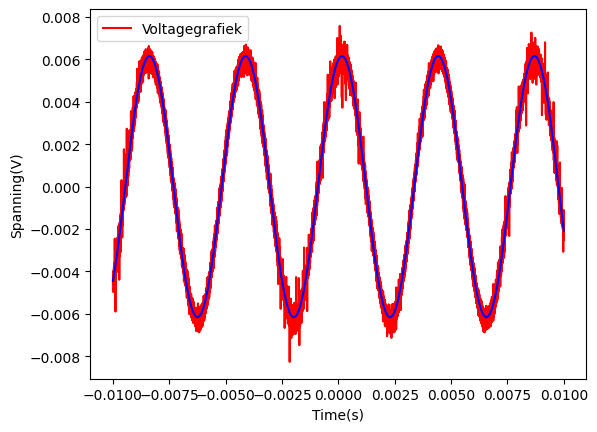

In [33]:
df = pd.read_csv("usr_wf_C1_data_2.csv", skiprows=12, names=["Time", "Voltage"])
Times = df["Time"]
Voltage = df["Voltage"]

def Fit_Functie(t, f, Amplitude, fase):
    return Amplitude*np.sin(2*np.pi*f*t + fase)

val, cov = curve_fit(Fit_Functie, Times, Voltage, p0=[200, 0.006, 0.75])
print(val[0])
plt.figure()

plt.xlabel("Time(s)")
plt.ylabel("Spanning(V)")
plt.plot(Times,Voltage,'r', label="Voltagegrafiek")
plt.plot(Times, Fit_Functie(Times, val[0], val[1], val[2]), 'b')

plt.legend()

plt.show()


De volgende stap was om de spankracht en de lengte van de draad te varieëren om zo voor de frequentie een grafiek te kunnen vinden.

Uiteindelijk hebben we drie gewichten elke keer op verschillende afstanden van een kantelpunt gehangen om op die manier de hefboomkracht te varieëren en daarmee ook de spankracht. De gewichten waren 1040 gr, 700 gr, 340 gr en we hebben ze op 20cm, 16cm, 12cm, 8cm gehangen. De lengte van de draad was 35cm.
De Frequentie is bepaald met behulp van een FFT met een Timebase van 0.5s, de scale van de driver was 2.00mV.

C:\Users\lucas\AppData\Local\Temp\ipykernel_2528\2041477141.py:20: RuntimeWarning: invalid value encountered in sqrt
  return (np.sqrt(T/mu))/(2*0.35)


[5.26914825e-05]
269.4554717507999
234.17001068200443
205.8085034512458
174.81776881242413


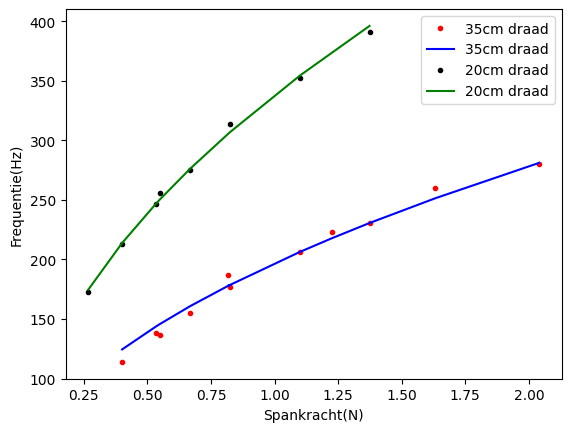

In [40]:
df1 = pd.read_csv("usr_wf_C1_data_2.csv", skiprows=12, names=["Time", "Voltage"])
df2 = pd.read_csv("usr_wf_C1_data_3.csv", skiprows=12, names=["Time", "Voltage"])
df3 = pd.read_csv("usr_wf_data_4.csv", skiprows=12, names=["Time", "Voltage"])
df4 = pd.read_csv("usr_wf_data_5.csv", skiprows=12, names=["Time", "Voltage"])

Data_Time = np.array([df1["Time"], df2["Time"], df3["Time"], df4["Time"]])
Data_Voltage = np.array([df1["Voltage"], df2["Voltage"], df3["Voltage"], df4["Voltage"]])
Test_Spankracht = [0.66706+1.3734, 1.09872+0.5334, 1.3734, 0.82404+0.40023, 1.09872, 0.54936+0.26682,
                    0.82404, 0.66706, 0.54936,
                    0.5334, 0.40023
                   ]
Test_frequentie = [280, 260, 231, 223, 206, 187,
                      177, 155, 137,
                    138, 114
                   ]
Test_Spankracht_2 = [1.3734, 1.09872, 0.82404, 0.66706, 0.54936, 0.5334, 0.40023, 0.26682]
Metingen = []
Test_frequentie_2 = [391, 352, 314, 275, 256, 247, 213, 173]
def Fit_Functie_2(T, mu):
    return (np.sqrt(T/mu))/(2*0.35)
val1, cov1 = curve_fit(Fit_Functie_2, Test_Spankracht, Test_frequentie)
val2, cov2 = curve_fit(Fit_Functie_2, Test_Spankracht_2, Test_frequentie_2)
print(val1)
for i in range(4):
    val, cov = curve_fit(Fit_Functie, Data_Time[i-1], Data_Voltage[i-1], p0=[200, 0.006, 0.75])
    print(val[0])
    Metingen.append(val[0])

plt.figure()

plt.plot(Test_Spankracht, Test_frequentie, 'r.', label="35cm draad")
plt.plot(Test_Spankracht, Fit_Functie_2(Test_Spankracht, val1[0]), 'b', label="35cm draad")
plt.plot(Test_Spankracht_2, Test_frequentie_2, 'k.', label="20cm draad")
plt.plot(Test_Spankracht_2, Fit_Functie_2(Test_Spankracht_2, val2[0]), 'g', label="20cm draad")
plt.xlabel("Spankracht(N)")
plt.ylabel("Frequentie(Hz)")
plt.legend()

plt.show()
